# 11_Ridge Regression

# Ridge Regression

10강에서는 Model이 Training Data에 지나치게 맞추어지는 Overfitting을 살펴보았다.

특히 높은 Degree의 Polynomial Regression은 매우 복잡한 Curve를 만들 수 있다.

이번에는 다음 Problem을 생각해 보자.

> Model의 복잡한 변화를 억제하면서 Regression을 수행할 수 있을까?

Ridge Regression은 Weight가 지나치게 커지는 것을 억제하여 Overfitting을 줄이는 방법이다.

## Review: Least Squares

Linear Regression에서는 Actual Value와 Prediction 사이의 Error를 최소화한다.

$$
\text{MSE}
=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

Training의 목적은 이 Error가 작아지도록 Weight를 결정하는 것이다.

Polynomial Regression에서도

$$
x,\;x^2,\;x^3,\ldots
$$

를 Features로 만든 후 동일한 Linear Regression을 수행하였다.

## A Problem with Large Weights

복잡한 Model에서는 일부 Weight가 매우 큰 값을 가질 수 있다.

예를 들어

$$
\hat{y}
=
w_1x+w_2x^2+\cdots+w_{10}x^{10}+b
$$

에서 일부 Weight가 매우 커지면 Input의 작은 변화에도 Prediction이 크게 변할 수 있다.

이러한 Model은 Training Data의 작은 변화나 Noise까지 따라갈 수 있다.

따라서 Error뿐만 아니라 Weight의 크기도 함께 고려하는 방법을 생각할 수 있다.

## Ridge Regression

Ridge Regression은 Prediction Error에 Weight의 크기에 대한 Penalty를 추가한다.

Linear Regression:

$$
\min_w
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

Ridge Regression:

$$
\min_w
\left[
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
+
\alpha\sum_{j=1}^{p}w_j^2
\right]
$$

첫 번째 항은 Prediction Error이다.

두 번째 항은 Weight가 커지는 것에 대한 Penalty이다.

$\alpha$는 두 항 사이의 중요도를 결정한다.

## Role of Alpha

$\alpha$는 Ridge Regression에서 Regularization의 강도를 결정한다.

$\alpha$가 작으면:

Weight에 대한 Penalty가 작다.

$\alpha$가 크면:

큰 Weight에 더 강한 Penalty가 적용된다.

따라서

$$
\alpha \uparrow
\quad\Rightarrow\quad
\text{Stronger Regularization}
$$

이다.

$\alpha=0$이면 Ridge Regression은 일반 Linear Regression과 같은 Optimization Problem이 된다.

In [32]:
# from google.colab import drive

# # Google Drive를 Colab에 Mount
# drive.mount('/content/drive')

# # 강의용 Data가 저장된 Folder

# data_path = "/content/drive/My Drive/Colab Notebooks/0_ML/Input/"

In [33]:
data_path = "../Input/"

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Data
df = pd.read_csv(data_path+"another2_data.csv")

X = df[["x"]]
y = df["y"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Create a Complex Model

Ridge Regression의 효과를 관찰하기 위해 높은 Degree의 Polynomial Features를 사용한다.

Degree 10:

$$
x,\;x^2,\;x^3,\ldots,x^{10}
$$

먼저 일반 Linear Regression을 적용한다.

In [35]:
# Degree 10 Polynomial Features
poly = PolynomialFeatures(
    degree=10,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train_poly, y_train)

# Prediction
train_pred = linear_model.predict(X_train_poly)
test_pred = linear_model.predict(X_test_poly)

print(
    "Train MSE:",
    mean_squared_error(y_train, train_pred)
)

print(
    "Test MSE:",
    mean_squared_error(y_test, test_pred)
)

Train MSE: 1.8931302279863342
Test MSE: 2.848318688671511


## Apply Ridge Regression

같은 Polynomial Features에 Ridge Regression을 적용한다.

Data도 같고 Polynomial Degree도 같다.

달라지는 것은 Training 방법이다.

Linear Regression:

Prediction Error를 최소화한다.

Ridge Regression:

Prediction Error와 Weight Penalty를 함께 최소화한다.

In [36]:
# Ridge Regression
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_poly, y_train)

# Prediction
ridge_train_pred = ridge_model.predict(X_train_poly)
ridge_test_pred = ridge_model.predict(X_test_poly)

print(
    "Train MSE:",
    mean_squared_error(y_train, ridge_train_pred)
)

print(
    "Test MSE:",
    mean_squared_error(y_test, ridge_test_pred)
)

Train MSE: 1.8942243686462796
Test MSE: 2.841777351320663


## What Happened to the Weights?

Ridge Regression의 목적은 Weight가 지나치게 커지는 것을 억제하는 것이다.

두 Model에서 학습된 Weight를 직접 비교해 보자.

In [37]:
weights = pd.DataFrame({
    "Feature": [
        f"x^{i}" for i in range(1, 11)
    ],
    "Linear": linear_model.coef_,
    "Ridge": ridge_model.coef_
})

display(weights)

,Feature,Linear,Ridge
0,x^1,1.418036e-01,0.144793
1,x^2,-1.761224e+00,-1.657289
2,x^3,7.163258e-02,0.071622
3,x^4,1.381410e-01,0.108168
4,x^5,-1.512135e-02,-0.015142
5,x^6,-3.924893e-03,-0.000707
6,x^7,8.450759e-04,0.000844
7,x^8,6.572722e-05,-0.000080
8,x^9,-1.450169e-05,-0.000014
9,x^10,7.798046e-07,0.000003


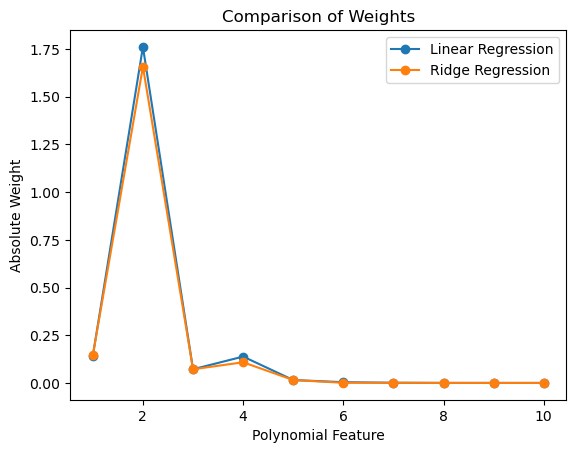

In [38]:
# Weight 크기 비교
plt.plot(
    range(1, 11),
    np.abs(linear_model.coef_),
    marker="o",
    label="Linear Regression"
)

plt.plot(
    range(1, 11),
    np.abs(ridge_model.coef_),
    marker="o",
    label="Ridge Regression"
)

plt.xlabel("Polynomial Feature")
plt.ylabel("Absolute Weight")
plt.title("Comparison of Weights")
plt.legend()

plt.show()

## Weight Shrinkage

Ridge Regression을 적용하면 Weight의 크기가 억제된다.

이러한 효과를 Weight Shrinkage라고 한다.

Ridge Regression은 Feature를 제거하는 것이 아니라 Weight의 크기를 줄이는 방향으로 Model을 학습한다.

즉,

> Error를 줄이는 것과 Weight를 작게 유지하는 것 사이에서 Balance를 찾는다.

## Change Alpha

Ridge Regression에서 중요한 Parameter는 $\alpha$이다.

$\alpha$가 변하면 Regularization의 강도가 달라진다.

다음 값을 비교해 보자.

$$
\alpha=0.01,\;0.1,\;1,\;10,\;100
$$

각 경우의 Train MSE와 Test MSE를 확인한다.

In [39]:
alphas = [0.01, 0.1, 1, 10, 100]

results = []

for alpha in alphas:

    model = Ridge(alpha=alpha)
    model.fit(X_train_poly, y_train)

    train_pred = model.predict(X_train_poly)
    test_pred = model.predict(X_test_poly)

    results.append({
        "Alpha": alpha,
        "Train MSE": mean_squared_error(
            y_train,
            train_pred
        ),
        "Test MSE": mean_squared_error(
            y_test,
            test_pred
        )
    })

results = pd.DataFrame(results)

display(results)

,Alpha,Train MSE,Test MSE
0,0.01,1.893130,2.848239
1,0.10,1.893143,2.847535
2,1.00,1.894224,2.841777
3,10.00,1.937990,2.839686
4,100.00,2.111080,2.918018


## Effect of Alpha

$\alpha$가 너무 작으면 Ridge Regression의 효과가 작다.

$\alpha$가 증가하면 Weight에 대한 Penalty가 강해진다.

그러나 $\alpha$가 지나치게 크면 Model이 필요한 Pattern까지 충분히 표현하지 못할 수 있다.

따라서 Regularization에서도 적절한 $\alpha$를 선택해야 한다.

$$
\text{Small }\alpha
\rightarrow
\text{Weak Regularization}
$$

$$
\text{Large }\alpha
\rightarrow
\text{Strong Regularization}
$$

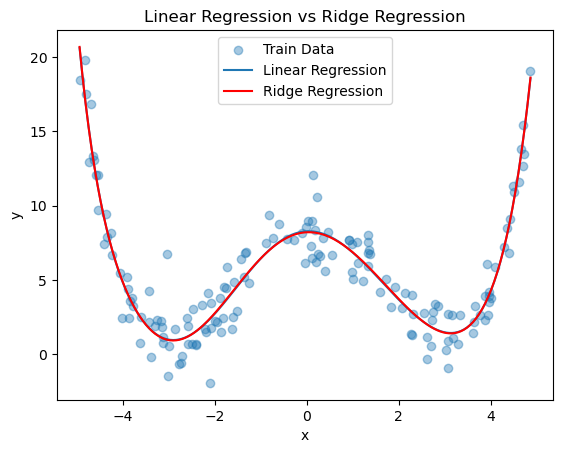

In [40]:
# Curve를 그리기 위한 Input
x_curve = np.linspace(
    df["x"].min(),
    df["x"].max(),
    300
)

X_curve = pd.DataFrame({
    "x": x_curve
})

X_curve_poly = poly.transform(X_curve)

# Prediction
linear_curve = linear_model.predict(
    X_curve_poly
)

ridge_curve = ridge_model.predict(
    X_curve_poly
)

# Comparison
plt.scatter(
    X_train["x"],
    y_train,
    alpha=0.4,
    label="Train Data"
)

plt.plot(
    x_curve,
    linear_curve,
    label="Linear Regression"
)

plt.plot(
    x_curve,
    ridge_curve,
    label="Ridge Regression",
    color='r'
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression vs Ridge Regression")
plt.legend()

plt.show()

## Regularization

Ridge Regression과 같이 Model의 복잡성을 억제하여 Overfitting을 줄이는 방법을 Regularization이라고 한다.

Ridge Regression에서는 Weight의 제곱합을 Penalty로 사용한다.

$$
\alpha\sum_{j=1}^{p}w_j^2
$$

이를 L2 Regularization이라고 한다.

Ridge Regression의 핵심은 Model을 복잡하게 만드는 것을 완전히 금지하는 것이 아니다.

필요한 만큼 복잡한 Model을 사용하되 지나치게 큰 Weight에는 Cost를 부과하는 것이다.

## Summary

Linear Regression은 Prediction Error를 최소화한다.

Ridge Regression은 Prediction Error와 Weight Penalty를 함께 고려한다.

$$
\text{Error}
+
\alpha\sum w_j^2
$$

Ridge Regression은 Weight가 지나치게 커지는 것을 억제한다.

$\alpha$는 Regularization의 강도를 결정한다.

- Small $\alpha$: Weak Regularization
- Large $\alpha$: Strong Regularization

Regularization을 이용하면 Overfitting을 줄이고 새로운 Data에 대한 Generalization을 개선할 수 있다.

> Overfitting → Weight Penalty → Ridge Regression → Regularization

## Assignment - 문제 11

`Input/another14_data.csv`를 이용하여 Polynomial Regression과 Ridge Regression을 비교한다.

다음 조건을 사용한다.

- `test_size=0.2`
- `random_state=42`
- Polynomial Degree = 12
- Ridge Regression의 $\alpha = 0.01,\;0.1,\;1,\;10$

다음 질문에 답하시오.

- Regular Linear Regression의 Train MSE와 Test MSE를 소수점 셋째 자리까지 적으시오.
- $\alpha=0.01$인 Ridge Regression의 Test MSE를 소수점 셋째 자리까지 적으시오.
- $\alpha=0.1$인 Ridge Regression의 Test MSE를 소수점 셋째 자리까지 적으시오.
- $\alpha=1$인 Ridge Regression의 Test MSE를 소수점 셋째 자리까지 적으시오.
- $\alpha=10$인 Ridge Regression의 Test MSE를 소수점 셋째 자리까지 적으시오.
- 네 Ridge Models 중 Test MSE가 가장 작은 $\alpha$를 적으시오.
- 위 Model의 가장 큰 Absolute Weight를 소수점 셋째 자리까지 적으시오.

답만 제출하시오.